In [46]:
import get_ps_21cmEMU
import numpy as np
from getdist import MCSamples, plots
import torch
_ = torch.manual_seed(0)
import matplotlib.pyplot as plt
# plt.style.use('sty.mplstyle')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
plt.style.use('sty.mplstyle')

Using device: cuda


In [47]:
# calling the emulator and getting the 1D power spectrum training data set

redshift_value = 8.01
# fiducial parameters for the emulator
log_f_star10 = -1.2
alpha_star = 0.5
t_star = 0.55
log_f_esc10 = -1.3
alpha_esc = 0
log_f_star7_mini = -2.5
log_f_esc7_mini = -1.5
log_l_x = 40.0
log_l_x_mini = 41.5
nu_x_thresh = 500
sigma_8 = 0.8118


astro_params = {"F_STAR10": log_f_star10, 
          'ALPHA_STAR': alpha_star,
          't_STAR': t_star,
          'F_ESC10': log_f_esc10,
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }

ps_1_d = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
# noise_sigma = np.load("data/sigma_pk_z8.01_108_hours.npy")
noise_sigma = np.load("data/sigma_pk_z8.01.npy")



def get_traning_data(theta, num_simulations):
    " five parameters: F_STAR10, F_ESC10, ALPHA_STAR"

    if torch.is_tensor(theta):
        theta = theta.detach().cpu().numpy()
    arr_f_star_10 = theta[:, 0]
    arr_f_esc_10 = theta[:, 1]
    arr_alpha_star = theta[:, 2]
    arr_t_star = theta[:, 3]
    arr_NU_X_THRESH = theta[:, 4]


    # print(f_star_10, f_esc_10, alpha_star)

    ps_data = np.zeros((num_simulations, 32))

    for i in range(num_simulations):
        astro_params = {"F_STAR10": arr_f_star_10[i], 
          'ALPHA_STAR': arr_alpha_star[i],
          't_STAR': arr_t_star[i],
          'F_ESC10': arr_f_esc_10[i],
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': arr_NU_X_THRESH[i],
          'SIGMA_8': sigma_8
         }
        ps = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
        # noise_sigma = 0.05 * ps # 5% noise level
        # noise_sigma = 0.2 * ps # 5% noise level

        np.random.seed(i)  # for reproducibility
        ps_noisy = ps + np.random.normal(0, noise_sigma, size=ps.shape) # add noise to the power spectrum
        ps_data[i, :] = ps_noisy
        
    return ps_data

In [48]:
### three parameters: F_STAR10, F_ESC10, ALPHA_STAR model
import pickle
# NPE
with open("trained_models/npe_nsf_hidden_features_50_num_transforms_12.pkl", "rb") as f:
    posterior_npe_3_params = pickle.load(f)

# NLE 
with open("data/nle_posterior.pkl", "rb") as f:
    posterior_nle_3_params = pickle.load(f)

# NRE
with open("data/nre_posterior.pkl", "rb") as f:
    posterior_nre_3_params = pickle.load(f)

In [49]:
# Rebuild the MCMC theta_transform for the NLE/NRE posteriors.
# Pickling loses the transform's internal state (torch's Transform.__getstate__
# always clears the cached _inv, which _InverseTransform also uses to store its
# wrapped transform), so after unpickling in a new process the transform is
# broken and .sample() raises "AssertionError: _inv must not be None".
# Rebuilding it fresh from the (unaffected) prior fixes this.
from sbi.utils import mcmc_transform

posterior_nle_3_params.theta_transform = mcmc_transform(posterior_nle_3_params.potential_fn.prior)
posterior_nre_3_params.theta_transform = mcmc_transform(posterior_nre_3_params.potential_fn.prior)

In [50]:
ps_obs = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value) # test data for inference
ps_obs_torch = torch.tensor(ps_obs, dtype=torch.float32, device=device)

In [51]:
posterior_samples_NPE = posterior_npe_3_params.sample((1000,), x=ps_obs_torch)  # draw 1000 posterior samples

  0%|          | 0/1000 [00:00<?, ?it/s]

In [52]:

posterior_samples_NLE = posterior_nle_3_params.sample((1000,), x=ps_obs_torch)  # draw 1000 posterior samples

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

In [53]:
posterior_samples_NRE = posterior_nre_3_params.sample((1000,), x=ps_obs_torch)  # draw 1000 posterior samples

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

Removed no burn in
Removed no burn in
Removed no burn in


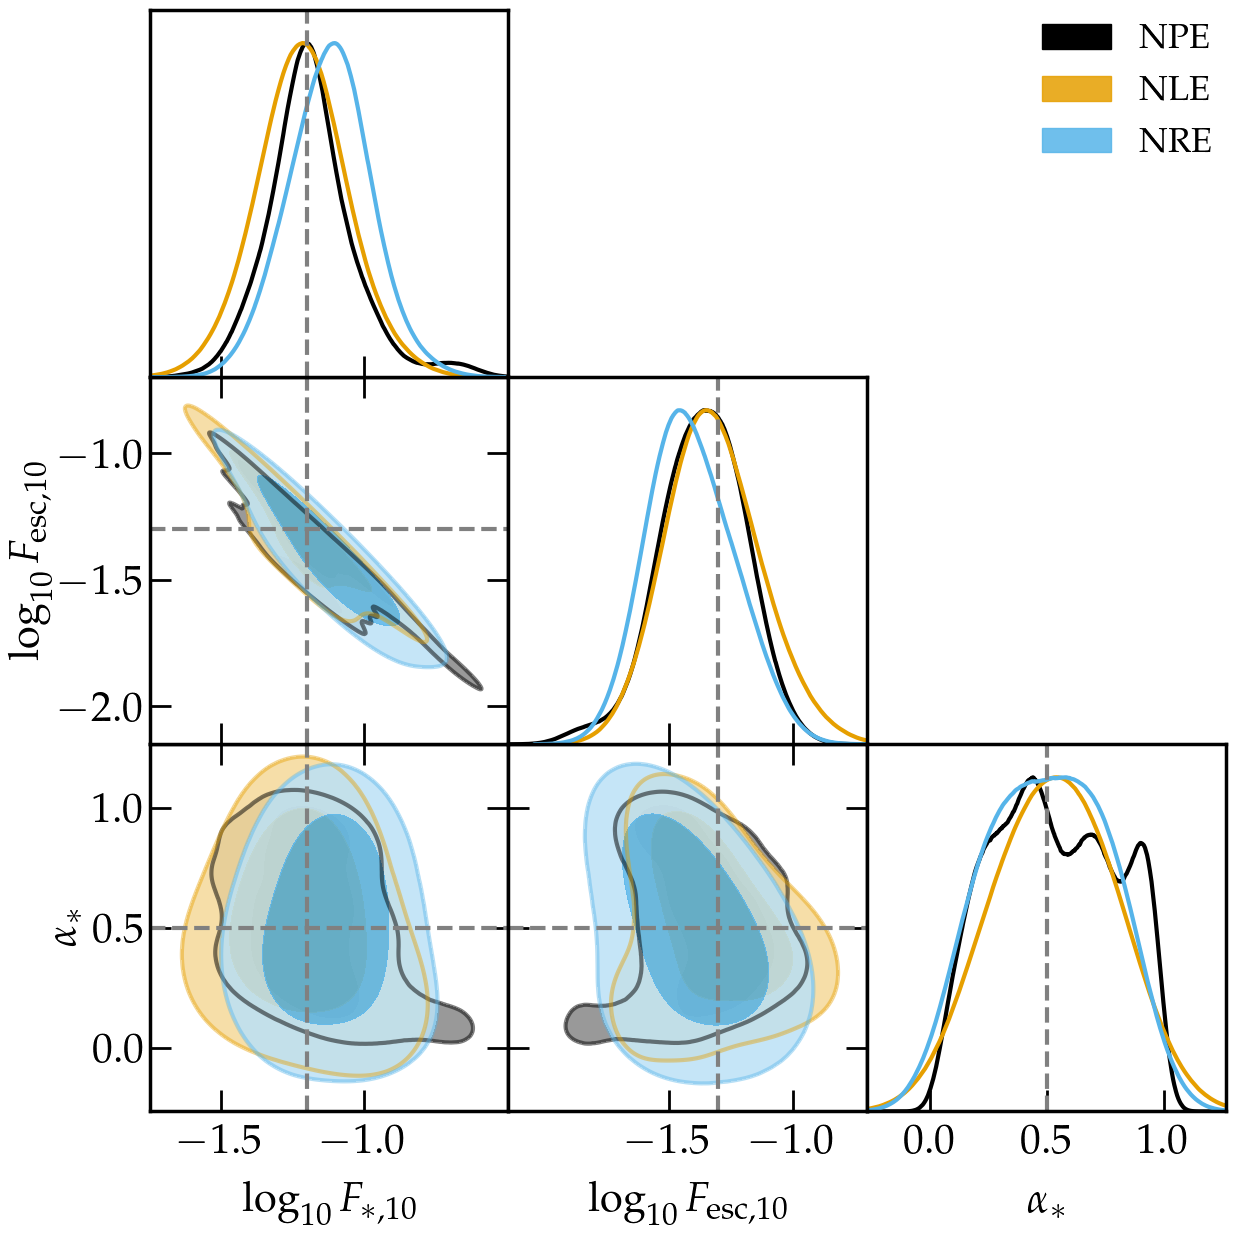

In [56]:
labels = [r'\log_{10} F_{*,10}', r'\log_{10} F_{\rm esc,10}', r'\alpha_{*}']
names = ['F_STAR10', 'F_ESC10', 'ALPHA_STAR']
true_params = [log_f_star10, log_f_esc10, alpha_star]

colorblind_safe = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#0072B2']
samples_NPE = MCSamples(
    samples=posterior_samples_NPE.cpu().numpy(), 
    names=names,
    labels=labels,
    label = "NPE"
)
samples_NLE = MCSamples(
    samples=posterior_samples_NLE.cpu().numpy(), 

    names=names,
    labels=labels,
    label = "NLE"
)
samples_NRE = MCSamples(
    samples=posterior_samples_NRE.cpu().numpy(),

    names=names,
    labels=labels,
    label = "NRE"
)

markers_dict = {name: val for name, val in zip(names, true_params)}
g = plots.get_subplot_plotter(width_inch=13, rc_sizes=True)
g.settings.axes_labelsize = 30
g.settings.legend_fontsize = 25

# g = plots.get_subplot_plotter()
g.triangle_plot([samples_NPE, samples_NLE, samples_NRE], 
                filled=True, markers=markers_dict, 
                contour_colors=colorblind_safe,)


for ax in g.fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(3.0)
    for collection in ax.collections:
        if hasattr(collection, 'set_linewidths'):
            collection.set_linewidths(3.0)

legend = g.fig.legends
for leg in legend:
    for line in leg.get_lines():
        line.set_linewidth(8.0)
plt.savefig("plots/triangle_plot_NPE_NLE_NRE_3_params.png", bbox_inches='tight', dpi = 150)